In [7]:
#import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# Load data*--
df = pd.read_csv(r'C:\Users\NITRO 5\Documents\Kuliah\Statprob\proyek1\proyek1-eda-kelompok-01\Attack_Dataset.csv')

In [9]:
# Cek 5 baris pertama
df.head()

,ID,Title,Category,Attack Type,Scenario Description,Tools Used,Attack Steps,Target Type,Vulnerability,MITRE Technique,Impact,Detection Method,Solution,Tags,Source,Unnamed: 15
0,1,Authentication Bypass via SQL Injection,Mobile Security,SQL Injection (SQLi),A login form fails to validate or sanitize inp...,"Browser, Burp Suite, SQLMap",1. Reconnaissance: Find a login form on the we...,"Web Login Portals (e.g., banking, admin dashbo...",Unsanitized input fields in SQL queries,"T1078 (Valid Accounts), T1190 (Exploit Public-...","Full account takeover, data theft, privilege e...","Web server logs, anomaly detection (e.g., logi...","Use prepared statements, Sanitize inputs, Limi...","SQLi, Authentication Bypass, Web Security, OWA...","OWASP, MITRE ATT&CK, DVWA",NaN
1,2,Union-Based SQL Injection,AI Agents & LLM Exploits,SQL Injection,This attack occurs when a hacker uses the SQL ...,"SQLMap, Burp Suite, Havij, Browser Developer T...",1. Identify User Input Points: Attacker finds ...,"Web Applications, Login Pages, Search Forms",Improperly filtered input fields that allow SQ...,T1190 – Exploit Public-Facing Application,"Data leakage, Credential theft, Account takeov...",Web Application Firewalls (WAF)Log AnalysisInp...,Use parameterized queries (Prepared Statements...,#SQLInjection #WebSecurity #UnionAttack #OWASP...,"OWASP, MITRE ATT&CK, Acunetix, PortSwigger Web...",NaN
2,3,Error-Based SQL Injection,AI Agents & LLM Exploits,SQL Injection,This attack occurs when an attacker intentiona...,"SQLMap, Burp Suite, Manual Browser Testing, Havij",1. Identify Input Points:Attacker finds a fiel...,"Web Applications, Login Forms, URL Parameters,...",Error message exposure due to lack of input va...,T1190 – Exploit Public-Facing Application,"Information disclosure, Database structure exp...",Review and monitor error logsEnable generic er...,Turn off detailed error messages in production...,#SQLInjection #ErrorLeakage #WebAppSecurity #O...,"OWASP, MITRE ATT&CK, Acunetix, PortSwigger Web...",NaN
3,4,Blind SQL Injection,AI Agents & LLM Exploits,SQL Injection,"In Blind SQL Injection, the attacker doesn’t s...","SQLMap, Burp Suite, sqlninja, Manual Browser T...",1. Find a User Input Point:Attacker finds a pl...,"Web Applications, Login Pages, Search Fields, ...","No error messages, but user input is still pas...",T1190 – Exploit Public-Facing Application,Slow and stealthy data theftFull database comp...,Monitor for slow and repetitive requestsAnalyz...,Use parameterized queries (prepared statements...,#BlindSQLi #TimeBasedSQLi #WebAppSecurity #OWA...,"OWASP, MITRE ATT&CK, Acunetix, PortSwigger, SQ...",NaN
4,5,Second-Order SQL Injection,AI Agents & LLM Exploits,SQL Injection,"In a Second-Order SQL Injection, the attacker ...","Burp Suite, SQLMap, Postman, Browser Dev Tools...",1. Identify Stored Input Fields:The attacker l...,"Web Applications, User Registration Forms, Pro...",Trusting previously stored unvalidated data in...,T1505.003 – SQL Injection,Delayed data theftUnexpected system behaviorSe...,Log monitoring for delayed query failuresTrack...,Sanitize and validate inputs both at entry and...,#SecondOrderSQLi #DelayedInjection #StoredInje...,"OWASP, MITRE ATT&CK, PortSwigger Academy, Acun...",NaN


## A. Pemeriksaan Kualitas Data
Berikut ini adalah kumpulan kode untuk memeriksa kualitas data pada dataset:

### 1. Pemeriksaan Tipe Data

Pemeriksaan tipe data dilakukan menggunakan `df.info()` untuk mengetahui jumlah data, jumlah kolom, jumlah nilai yang tersedia, dan tipe data pada setiap kolom.

Pemeriksaan ini bertujuan untuk memastikan bahwa tipe data setiap kolom sudah sesuai dengan jenis informasinya dan tidak terdapat data yang seharusnya berupa angka tetapi terbaca sebagai teks.

In [10]:
#Tipe data setiap kolom
print("\nTipe data setiap kolom")
print(df.info())


Tipe data setiap kolom
<class 'pandas.DataFrame'>
RangeIndex: 14133 entries, 0 to 14132
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   ID                    14133 non-null  int64
 1   Title                 14133 non-null  str  
 2   Category              14133 non-null  str  
 3   Attack Type           14133 non-null  str  
 4   Scenario Description  14133 non-null  str  
 5   Tools Used            14119 non-null  str  
 6   Attack Steps          14133 non-null  str  
 7   Target Type           14129 non-null  str  
 8   Vulnerability         14115 non-null  str  
 9   MITRE Technique       14109 non-null  str  
 10  Impact                14130 non-null  str  
 11  Detection Method      14129 non-null  str  
 12  Solution              14130 non-null  str  
 13  Tags                  14130 non-null  str  
 14  Source                13973 non-null  str  
 15  Unnamed: 15           46 non-null     st

Dataset terdiri dari 14.133 baris dan 16 kolom. Kolom `ID` memiliki tipe data `int64`, sedangkan sebagian besar kolom lainnya bertipe `str` karena berisi informasi berbentuk teks.

Ditemukan kolom `Unnamed: 15` yang hampir seluruh nilainya kosong, sehingga kolom tersebut tidak memberikan informasi yang berarti untuk analisis.

### 2. Pemeriksaan Baris dan Kolom

Pemeriksaan Baris dan Kolom dilakukan untuk mengetahui jumlahnya. Fungsi `df.shape()` digunakan untuk jumlah masing-masing baris dan kolom. 

In [11]:
# Berapa baris dan kolom?
print("\nBaris, Kolom:", df.shape)


Baris, Kolom: (14133, 16)


Diketahui bahwa terdapat 14.133 baris dan 16 kolom

### 3. Pemeriksaan Nama Kolom

Pemeriksaan ini dilakukan untuk mengetahui nama dari masing masing kolom dataset

In [12]:
# Nama kolom
print("\nKolom:")
print(df.columns.tolist())


Kolom:
['ID', 'Title', 'Category', 'Attack Type', 'Scenario Description', 'Tools Used', 'Attack Steps ', 'Target Type', 'Vulnerability', 'MITRE Technique', 'Impact', 'Detection Method', 'Solution', 'Tags', 'Source', 'Unnamed: 15']


Output diatas adalah nama-nama kolom yang dihasilkan dari fungsi `df.column.tolist()`.

### 4. Pemeriksaan Data Duplikat

Pemeriksaan duplikat dilakukan untuk mengetahui apakah terdapat baris yang memiliki data yang sama secara keseluruhan. Fungsi `df.duplicated()` digunakan untuk mendeteksi baris duplikat, kemudian `.sum()` digunakan untuk menghitung jumlahnya.

In [13]:
# Duplikat
print("\nJumlah duplikat:", df.duplicated().sum())


Jumlah duplikat: 0


Output kode menumjukkan bahwa pada dataset ini tidak ditemukan duplikat.

### 5. Pemeriksaan Missing Values

Pemeriksaan ini berguna untuk mengetahui jumlah data yang kosong (missing values) pada setiap kolom dalam dataset. Fungsi `df.isna()` digunakan untuk mendeteksi data yang kosong, kemudian `.sum()` menghitung jumlah missing values pada masing-masing kolom.

In [14]:
# Missing values per kolom
print("Missing values:")
print(df.isna().sum())

Missing values:
ID                          0
Title                       0
Category                    0
Attack Type                 0
Scenario Description        0
Tools Used                 14
Attack Steps                0
Target Type                 4
Vulnerability              18
MITRE Technique            24
Impact                      3
Detection Method            4
Solution                    3
Tags                        3
Source                    160
Unnamed: 15             14087
dtype: int64


Berdasarkan hasil pemeriksaan, masih terdapat missing values pada beberapa kolom, yaitu `Target Type` sebanyak 4 data, `Impact` sebanyak 3 data, `Detection Method` sebanyak 4 data, `Solution` sebanyak 3 data, dan `Tags` sebanyak 3 data. Kolom lainnya tidak memiliki missing values.

### 6. Persentase Missing Values

Selain mengetahui jumlah missing values, persentasenya juga diperiksa untuk mengetahui seberapa besar proporsi data kosong dibandingkan dengan keseluruhan jumlah data.

Persentase missing values dihitung dengan membagi jumlah data kosong pada setiap kolom dengan jumlah seluruh baris, kemudian dikalikan 100.

In [15]:
# Persentase missing
print("\nPersentase missing:")
print((df.isna().sum() / len(df)) * 100)


Persentase missing:
ID                       0.000000
Title                    0.000000
Category                 0.000000
Attack Type              0.000000
Scenario Description     0.000000
Tools Used               0.099059
Attack Steps             0.000000
Target Type              0.028303
Vulnerability            0.127361
MITRE Technique          0.169815
Impact                   0.021227
Detection Method         0.028303
Solution                 0.021227
Tags                     0.021227
Source                   1.132102
Unnamed: 15             99.674521
dtype: float64


Hasil menunjukkan bahwa missing values hanya terdapat pada beberapa kolom, yaitu `Target Type` sebesar 0,0283%, `Impact` sebesar 0,0212%, `Detection Method` sebesar 0,0283%, `Solution` sebesar 0,0212%, dan `Tags` sebesar 0,0212%. Persentase missing values tersebut sangat kecil dibandingkan dengan jumlah keseluruhan data.

### 5. Keputusan dan Pembersihan Data

Berdasarkan hasil pemeriksaan, kolom `Unnamed: 15` akan dihapus karena sebagian besar nilainya kosong dan tidak memberikan informasi yang relevan.

Missing values pada kolom yang berisi informasi penting tidak dihapus karena jumlahnya sangat kecil. Untuk mempertahankan seluruh baris dataset, missing values akan diganti dengan nilai `Unknown`.

Data duplikat tidak perlu ditangani karena tidak ditemukan baris duplikat.

In [16]:
# 1. Drop kolom kosong
df = df.drop(columns=['Unnamed: 15'])

Kode ini berfungsi untuk menghapus kolom yang tidak diperlukan.

In [17]:
# 2. isi missing dengan "Unknown"
df = df.fillna('Unknown')

Kode ini berfungsi untuk mengisi seluruh missing values dengan "Unknown".

### 6. Pemeriksaan Ulang Setelah Pembersihan

Setelah proses pembersihan dilakukan, dataset diperiksa kembali untuk memastikan bahwa kolom yang tidak diperlukan telah dihapus dan tidak terdapat lagi missing values.

In [18]:
print("Missing values setelah cleaning:")
print(df.isna().sum())

print("\nUkuran dataset setelah cleaning:")
print(df.shape)

Missing values setelah cleaning:
ID                      0
Title                   0
Category                0
Attack Type             0
Scenario Description    0
Tools Used              0
Attack Steps            0
Target Type             0
Vulnerability           0
MITRE Technique         0
Impact                  0
Detection Method        0
Solution                0
Tags                    0
Source                  0
dtype: int64

Ukuran dataset setelah cleaning:
(14133, 15)


### 7. Kesimpulan Pemeriksaan Kualitas Data

Berdasarkan pemeriksaan kualitas data, dataset awal terdiri dari 14.133 baris dan 16 kolom. Ditemukan beberapa missing values pada sejumlah kolom, tetapi persentasenya sangat kecil dibandingkan dengan keseluruhan data. Selain itu, tidak ditemukan adanya data duplikat.

Kolom `Unnamed: 15` dihapus karena sebagian besar nilainya kosong dan tidak memberikan informasi yang relevan. Missing values pada kolom lainnya tidak dihapus karena jumlahnya sangat kecil dan penghapusan baris dapat mengurangi jumlah data. Sebagai gantinya, missing values diisi dengan nilai `Unknown`.

Setelah proses pembersihan, dataset memiliki 14.133 baris dan 15 kolom serta tidak memiliki missing values. Dengan demikian, dataset telah melalui tahap pembersihan dasar dan siap digunakan untuk tahap  selanjutnya.

## B. Pemeriksaan Nilai Unik

Pemeriksaan nilai unik dilakukan untuk melihat variasi data pada setiap kolom. Hal ini membantu mengidentifikasi kolom kategorikal yang memiliki terlalu banyak variasi atau kemungkinan terdapat ketidakkonsistenan dalam penulisan data.

Jumlah nilai unik pada setiap kolom diperiksa menggunakan `nunique()`.

In [18]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique")

ID: 14133 unique
Title: 13793 unique
Category: 64 unique
Attack Type: 8834 unique
Scenario Description: 13866 unique
Tools Used: 12936 unique
Attack Steps : 13895 unique
Target Type: 9885 unique
Vulnerability: 13425 unique
MITRE Technique: 5771 unique
Impact: 13187 unique
Detection Method: 13813 unique
Solution: 13852 unique
Tags: 13817 unique
Source: 7052 unique


## C. Pemeriksaan Nilai pada Kolom Kategorikal

Setelah melihat jumlah nilai unik pada setiap kolom, dilakukan pemeriksaan lebih lanjut pada beberapa kolom kategorikal untuk melihat variasi dan pola penulisan datanya.

Pemeriksaan dilakukan menggunakan `value_counts()` untuk melihat jumlah kemunculan setiap kategori, serta menampilkan beberapa contoh nilai pada kolom yang memiliki format lebih kompleks. Hasil pemeriksaan ini digunakan sebagai dasar untuk menentukan proses standarisasi data selanjutnya.

In [19]:
# 1. Cek Category (64 unique, masih mungkin dibaca)
print("=== CATEGORY ===")
print(df['Category'].value_counts())

=== CATEGORY ===
Category
Insider Threat                                           569
Physical / Hardware Attacks                              548
Quantum Cryptography & Post-Quantum Threats              542
Wireless Attacks (Advanced)                              535
Malware & Threat                                         528
                                                        ... 
Automotive / CPS → Sensor Spoofing                         7
Automotive / CPS → Firmware Over-The-Air (FOTA) Abuse      5
Automotive / CPS → Physical Layer Attack                   3
Network security                                           2
 Mobile Security                                           1
Name: count, Length: 64, dtype: int64


In [20]:
# 2. Cek Target Type (9.885 unique, lihat 20 teratas)
print("\n=== TARGET TYPE (Top 20) ===")
print(df['Target Type'].value_counts().head(20))


=== TARGET TYPE (Top 20) ===
Target Type
Windows                     291
Workstation                 109
Satellite                    78
Endpoint                     50
Android App                  46
Windows Host                 42
Wireless Networks            36
GitHub Actions               36
Infotainment System          35
Windows Workstation          34
PLC                          33
Internal Network             31
Passenger Vehicle            31
ECU                          30
Android Device               28
Ethereum Smart Contracts     28
Wallet Users                 28
Windows Hosts                26
Workstations                 26
Kubernetes Cluster           25
Name: count, dtype: int64


In [21]:
# 3. Cek Tags (formatnya apa?)
print("\n=== TAGS (5 contoh) ===")
print(df['Tags'].dropna().head(5).tolist())


=== TAGS (5 contoh) ===
['SQLi, Authentication Bypass, Web Security, OWASP Top 10', '#SQLInjection #WebSecurity #UnionAttack #OWASPTop10 #InjectionFlaws', '#SQLInjection #ErrorLeakage #WebAppSecurity #OWASPTop10 #DatabaseSecurity', '#BlindSQLi #TimeBasedSQLi #WebAppSecurity #OWASPTop10 #DatabaseHacking', '#SecondOrderSQLi #DelayedInjection #StoredInjection #WebSecurity #OWASPTop10']


In [22]:
# 4. Cek Tools Used (formatnya apa?)
print("\n=== TOOLS USED (5 contoh) ===")
print(df['Tools Used'].dropna().head(5).tolist())


=== TOOLS USED (5 contoh) ===
['Browser, Burp Suite, SQLMap', 'SQLMap, Burp Suite, Havij, Browser Developer Tools', 'SQLMap, Burp Suite, Manual Browser Testing, Havij', 'SQLMap, Burp Suite, sqlninja, Manual Browser Testing, Python Scripts', 'Burp Suite, SQLMap, Postman, Browser Dev Tools, Manual Testing']


In [23]:
# 5. Cek MITRE Technique (formatnya apa?)
print("\n=== MITRE (5 contoh) ===")
print(df['MITRE Technique'].dropna().head(5).tolist())


=== MITRE (5 contoh) ===
['T1078 (Valid Accounts), T1190 (Exploit Public-Facing App)', 'T1190 – Exploit Public-Facing Application', 'T1190 – Exploit Public-Facing Application', 'T1190 – Exploit Public-Facing Application', 'T1505.003 – SQL Injection']


**Hasil pemeriksaan:**

Pemeriksaan menunjukkan bahwa beberapa kolom memiliki variasi nilai yang cukup beragam. Pada data kategorikal, terdapat perbedaan format penulisan seperti penggunaan huruf kapital dan spasi yang tidak konsisten. Oleh karena itu, dilakukan standarisasi teks menggunakan `strip()` dan `title()` agar penulisan data menjadi lebih seragam sebelum dilakukan proses pengelompokan.

## D. Standarisasi Teks

Standarisasi teks dilakukan untuk menyeragamkan penulisan pada data kategorikal. 
Pada tahap ini digunakan `strip()` untuk menghapus spasi yang tidak diperlukan 
di awal dan akhir teks, serta `title()` untuk menyeragamkan penggunaan huruf 
kapital pada setiap kata.

Standarisasi diterapkan pada kolom kategorikal yang akan digunakan dalam analisis.

### 1. Proses Standarisasi

Setiap kolom yang telah dipilih akan diproses menggunakan `strip()` dan `title()`. 
`strip()` digunakan untuk menghilangkan spasi kosong di awal dan akhir teks, 
sedangkan `title()` digunakan untuk membuat huruf awal setiap kata menjadi kapital.

In [19]:
# Kolom kategorikal yang akan distandarisasi
text_cols = [
    'Category',
    'Attack Type',
    'Target Type',
    'Impact',
    'Detection Method',
    'Source'
]

### Pemeriksaan Setelah Standarisasi

Setelah standarisasi dilakukan, data diperiksa kembali untuk memastikan format penulisan pada kolom kategorikal telah menjadi lebih konsisten.

In [64]:
# Melakukan perulangan untuk setiap kolom yang terdapat dalam text_cols
for col in text_cols:
    
    # Menampilkan nama kolom sebagai judul
    print(f"\n=== {col} ===")
    
    # Menampilkan 5 nilai yang paling sering muncul pada kolom tersebut
    print(df[col].value_counts().head())


=== Category ===
Category
Insider Threat                                 569
Physical / Hardware Attacks                    548
Quantum Cryptography & Post-Quantum Threats    542
Wireless Attacks (Advanced)                    535
Malware & Threat                               528
Name: count, dtype: int64

=== Attack Type ===
Attack Type
Hardware Interface Exploitation    161
Wireless Attacks (Advanced)         95
Dependency Confusion                91
Fuzzer Configuration                75
Malicious Libraries                 74
Name: count, dtype: int64

=== Target Type ===
Target Type
Windows        291
Workstation    109
Satellite       78
Endpoint        50
Android App     46
Name: count, dtype: int64

=== Impact ===
Impact
Credential theft         37
Credential Theft         30
Remote Code Execution    26
Remote code execution    20
T0856                    18
Name: count, dtype: int64

=== Detection Method ===
Detection Method
Registry + Prefetch + Memory                        

## E. Membuat Attack_Group dan Target_Group 

### 1. Mengetahui jumlah keseluruhan Attack Type dan Target Type 

In [66]:
print("Jumlah Attack Type unik:", df['Attack Type'].nunique())
print("Jumlah Target Type unik:", df['Target Type'].nunique())

Jumlah Attack Type unik: 8834
Jumlah Target Type unik: 9886


### 2. Mencatak seluruh Attack Type dan Target Type untuk membuat Attack_Group dan Target_Group

In [84]:
# Mengambil semua Attack Type unik dan mengubahnya menjadi DataFrame
attack_types = pd.DataFrame({
    'No': range(1, df['Attack Type'].dropna().nunique() + 1),
    'Attack Type': df['Attack Type'].dropna().unique()
})

# Menampilkan seluruh Attack Type dalam bentuk tabel
attack_types

,No,Attack Type
0,1,SQL Injection (SQLi)
1,2,SQL Injection
2,3,SQL Injection
3,4,Cross-Site Scripting (XSS)
4,5,CSRF (Cross-Site Request Forgery)
...,...,...
8829,8830,Supply Chain Simulation
8830,8831,Compliance Simulation
8831,8832,RF Interference Simulation
8832,8833,Filesystem Fault Simulation


In [87]:
# Mengambil semua Attack Type unik dan mengubahnya menjadi DataFrame
target_types = pd.DataFrame({
    'No': range(1, df['Target Type'].dropna().nunique() + 1),
    'Target Type': df['Target Type'].dropna().unique()
})

# Menampilkan seluruh Attack Type dalam bentuk tabel
target_types

,No,Target Type
0,1,"Web Login Portals (e.g., banking, admin dashbo..."
1,2,"Web Applications, Login Pages, Search Forms"
2,3,"Web Applications, Login Forms, URL Parameters,..."
3,4,"Web Applications, Login Pages, Search Fields, ..."
4,5,"Web Applications, User Registration Forms, Pro..."
...,...,...
9881,9882,Satellite OEM Firmware
9882,9883,Simulated Satellite Telemetry
9883,9884,Satellite Operators & SOC Teams
9884,9885,Simulated Satellite Networks


### 3. Membuat Kolom Attack_Group

Untuk menyederhanakan variasi jenis serangan: `Attack_Type`, dibuat kolom baru yaitu `Attack_Group`. Kolom ini mengelompokkan beberapa jenis serangan ke dalam kategori yang lebih umum menggunakan fungsi `simplify_attack()`.

In [88]:
def simplify_attack(x):
    x = str(x).lower()

    # SQL / NoSQL Injection
    if 'sql injection' in x or 'nosql injection' in x or 'orm injection' in x:
        return 'Injection - SQL'

    # Command Injection
    elif 'command injection' in x or 'os command' in x:
        return 'Injection - Command'

    # XSS / HTML / Script Injection
    elif any(k in x for k in [
        'xss', 'cross-site scripting', 'script injection',
        'html injection', 'javascript injection'
    ]):
        return 'Injection - XSS/Script'

    # Prompt Injection / LLM attacks
    elif any(k in x for k in [
        'prompt injection', 'prompt hijack', 'prompt poisoning',
        'prompt manipulation', 'goal override',
        'instruction injection'
    ]):
        return 'AI - Prompt Injection'

    # File Upload / File-based attacks
    elif any(k in x for k in [
        'file upload', 'uploaded file', 'file inclusion',
        'file overwrite', 'file read'
    ]):
        return 'File Attack'

    # Path Traversal / LFI / RFI
    elif any(k in x for k in [
        'path traversal', 'directory traversal',
        'lfi', 'rfi', 'local file inclusion',
        'remote file inclusion'
    ]):
        return 'File/Path Traversal'

    # Deserialization
    elif any(k in x for k in [
        'deserialization', 'deserialize', 'serialization exploit'
    ]):
        return 'Deserialization'

    # SSRF
    elif 'ssrf' in x or 'server-side request forgery' in x:
        return 'SSRF'

    # Authentication / Credential attacks
    elif any(k in x for k in [
        'credential', 'authentication bypass',
        'password attack', 'brute force',
        'credential stuffing', 'password spraying'
    ]):
        return 'Authentication/Credential'

    # Privilege Escalation
    elif 'privilege escalation' in x or 'privilege elevation' in x:
        return 'Privilege Escalation'

    # Phishing / Social Engineering
    elif any(k in x for k in [
        'phishing', 'spearphishing', 'social engineering'
    ]):
        return 'Phishing/Social Engineering'

    # Malware / Trojan / Backdoor
    elif any(k in x for k in [
        'malware', 'trojan', 'backdoor',
        'ransomware', 'rootkit', 'worm'
    ]):
        return 'Malware'

    # Supply Chain
    elif any(k in x for k in [
        'dependency confusion', 'malicious library',
        'malicious libraries', 'supply chain',
        'package poisoning'
    ]):
        return 'Supply Chain'

    # Data Exfiltration / Information Leakage
    elif any(k in x for k in [
        'data exfiltration', 'data leakage',
        'information disclosure', 'data extraction',
        'information leakage'
    ]):
        return 'Data Exfiltration/Leakage'

    # DoS / DDoS
    elif any(k in x for k in [
        'denial of service', 'dos', 'ddos',
        'resource exhaustion', 'zip bomb'
    ]):
        return 'DoS/DDoS'

    # Fuzzing
    elif 'fuzz' in x or 'fuzzer' in x:
        return 'Fuzzing'

    # Wireless
    elif any(k in x for k in [
        'wireless', 'wi-fi', 'wifi', 'bluetooth',
        'rf', 'radio'
    ]):
        return 'Wireless Attack'

    # Hardware / Physical
    elif any(k in x for k in [
        'hardware', 'physical', 'removable media',
        'usb', 'firmware'
    ]):
        return 'Hardware/Physical'

    # Cloud
    elif any(k in x for k in [
        'cloud', 'aws', 'azure', 'gcp'
    ]):
        return 'Cloud Attack'

    # Container / Kubernetes
    elif any(k in x for k in [
        'kubernetes', 'k8s', 'container', 'docker'
    ]):
        return 'Container/Kubernetes'

    # Adversarial ML / AI
    elif any(k in x for k in [
        'adversarial example', 'adversarial attack',
        'adversarial perturbation'
    ]):
        return 'AI - Adversarial'

    # Model / Training attacks
    elif any(k in x for k in [
        'model inversion', 'membership inference',
        'training data', 'model reconstruction',
        'data poisoning', 'model poisoning'
    ]):
        return 'AI - Model/Data Attack'

    # Kalau belum masuk kategori
    else:
        return 'Other'


df['Attack_Group'] = df['Attack Type'].apply(simplify_attack)

### 4. Mengecek distribusi Attack Group

Setelah kolom `Attack_Group` dibuat, dilakukan pengecekan jumlah data pada setiap kategori untuk melihat distribusi jenis serangan.

In [89]:
df['Attack_Group'].value_counts()

Attack_Group
Other                          9470
Wireless Attack                 886
Malware                         561
Hardware/Physical               475
Authentication/Credential       394
Supply Chain                    388
Phishing/Social Engineering     231
Privilege Escalation            223
Fuzzing                         199
Injection - XSS/Script          163
DoS/DDoS                        162
AI - Prompt Injection           149
Data Exfiltration/Leakage       128
File/Path Traversal             112
Cloud Attack                    105
Container/Kubernetes            102
SSRF                             94
AI - Model/Data Attack           85
Deserialization                  65
Injection - SQL                  43
File Attack                      40
Injection - Command              37
AI - Adversarial                 21
Name: count, dtype: int64

### 5. Membuat Kolom Target_Group

Selain jenis serangan, `Target Type` juga perlu disederhanakan agar kategori target lebih mudah dianalisis.

Dibuat kolom baru `Target_Group` yang berisi pengelompokan kategori target menggunakan fungsi `simplify_target()`.

In [90]:
def simplify_target(x):
    x = str(x).lower()

    # Web / Application
    if any(k in x for k in [
        'web application', 'web app', 'web portal', 'web server',
        'login page', 'login portal', 'web browser', 'browser',
        'api', 'website', 'application', 'app'
    ]):
        return 'Web/Application'

    # Windows / Desktop
    elif any(k in x for k in [
        'windows', 'workstation', 'desktop', 'laptop', 'pc'
    ]):
        return 'Desktop/OS'

    # Mobile
    elif any(k in x for k in [
        'android', 'ios', 'iphone', 'ipad', 'smartphone',
        'mobile phone', 'mobile device', 'mobile app'
    ]):
        return 'Mobile'

    # Network / Wireless
    elif any(k in x for k in [
        'wireless', 'wi-fi', 'wifi', 'network', 'router',
        'switch', 'vpn', 'access point', 'lan'
    ]):
        return 'Network'

    # Cloud / DevOps
    elif any(k in x for k in [
        'cloud', 'aws', 'azure', 'gcp', 'github', 'gitlab',
        'docker', 'kubernetes', 'ci/cd', 'terraform'
    ]):
        return 'Cloud/DevOps'

    # IoT / Embedded
    elif any(k in x for k in [
        'iot', 'smart device', 'embedded', 'sensor', 'smartwatch',
        'smart tv', 'firmware', 'wearable'
    ]):
        return 'IoT/Embedded'

    # Server / Database
    elif any(k in x for k in [
        'server', 'database', 'dbms', 'sql server', 'file server',
        'mail server'
    ]):
        return 'Server/Database'

    # Automotive
    elif any(k in x for k in [
        'vehicle', 'automotive', 'car', 'ecu', 'infotainment',
        'telematics'
    ]):
        return 'Automotive'

    # Physical / Hardware
    elif any(k in x for k in [
        'hardware', 'physical', 'usb', 'rfid', 'access card',
        'door', 'cctv'
    ]):
        return 'Physical/Hardware'

    # Satellite / Space
    elif any(k in x for k in [
        'satellite', 'spacecraft', 'space system'
    ]):
        return 'Satellite/Space'

    else:
        return 'Other'


df['Target_Group'] = df['Target Type'].apply(simplify_target)

### 6. Mengecek distribusi Target Group

Selanjutnya, dilakukan pengecekan jumlah data pada setiap kategori `Target_Group`.

In [91]:
df['Target_Group'].value_counts()

Target_Group
Other                6243
Web/Application      2185
Desktop/OS           1668
Network               984
Cloud/DevOps          966
Automotive            537
IoT/Embedded          518
Mobile                328
Server/Database       307
Satellite/Space       250
Physical/Hardware     147
Name: count, dtype: int64

## F. Menyimpan Dataset

Setelah proses pembersihan dan pengelompokan data selesai, dataset disimpan dalam format CSV untuk digunakan pada tahap analisis selanjutnya.

Parameter `index=False` digunakan agar index DataFrame tidak ikut disimpan sebagai kolom tambahan.

In [92]:
df.to_csv('attack_dataset_clean.csv', index=False)
df_check = pd.read_csv('attack_dataset_clean.csv')
df_check.head()

,ID,Title,Category,Attack Type,Scenario Description,Tools Used,Attack Steps,Target Type,Vulnerability,MITRE Technique,Impact,Detection Method,Solution,Tags,Source,Attack_Group,Target_Group
0,1,Authentication Bypass via SQL Injection,Mobile Security,SQL Injection (SQLi),A login form fails to validate or sanitize inp...,"Browser, Burp Suite, SQLMap",1. Reconnaissance: Find a login form on the we...,"Web Login Portals (e.g., banking, admin dashbo...",Unsanitized input fields in SQL queries,"T1078 (Valid Accounts), T1190 (Exploit Public-...","Full account takeover, data theft, privilege e...","Web server logs, anomaly detection (e.g., logi...","Use prepared statements, Sanitize inputs, Limi...","SQLi, Authentication Bypass, Web Security, OWA...","OWASP, MITRE ATT&CK, DVWA",Injection - SQL,Web/Application
1,2,Union-Based SQL Injection,AI Agents & LLM Exploits,SQL Injection,This attack occurs when a hacker uses the SQL ...,"SQLMap, Burp Suite, Havij, Browser Developer T...",1. Identify User Input Points: Attacker finds ...,"Web Applications, Login Pages, Search Forms",Improperly filtered input fields that allow SQ...,T1190 – Exploit Public-Facing Application,"Data leakage, Credential theft, Account takeov...",Web Application Firewalls (WAF)Log AnalysisInp...,Use parameterized queries (Prepared Statements...,#SQLInjection #WebSecurity #UnionAttack #OWASP...,"OWASP, MITRE ATT&CK, Acunetix, PortSwigger Web...",Injection - SQL,Web/Application
2,3,Error-Based SQL Injection,AI Agents & LLM Exploits,SQL Injection,This attack occurs when an attacker intentiona...,"SQLMap, Burp Suite, Manual Browser Testing, Havij",1. Identify Input Points:Attacker finds a fiel...,"Web Applications, Login Forms, URL Parameters,...",Error message exposure due to lack of input va...,T1190 – Exploit Public-Facing Application,"Information disclosure, Database structure exp...",Review and monitor error logsEnable generic er...,Turn off detailed error messages in production...,#SQLInjection #ErrorLeakage #WebAppSecurity #O...,"OWASP, MITRE ATT&CK, Acunetix, PortSwigger Web...",Injection - SQL,Web/Application
3,4,Blind SQL Injection,AI Agents & LLM Exploits,SQL Injection,"In Blind SQL Injection, the attacker doesn’t s...","SQLMap, Burp Suite, sqlninja, Manual Browser T...",1. Find a User Input Point:Attacker finds a pl...,"Web Applications, Login Pages, Search Fields, ...","No error messages, but user input is still pas...",T1190 – Exploit Public-Facing Application,Slow and stealthy data theftFull database comp...,Monitor for slow and repetitive requestsAnalyz...,Use parameterized queries (prepared statements...,#BlindSQLi #TimeBasedSQLi #WebAppSecurity #OWA...,"OWASP, MITRE ATT&CK, Acunetix, PortSwigger, SQ...",Injection - SQL,Web/Application
4,5,Second-Order SQL Injection,AI Agents & LLM Exploits,SQL Injection,"In a Second-Order SQL Injection, the attacker ...","Burp Suite, SQLMap, Postman, Browser Dev Tools...",1. Identify Stored Input Fields:The attacker l...,"Web Applications, User Registration Forms, Pro...",Trusting previously stored unvalidated data in...,T1505.003 – SQL Injection,Delayed data theftUnexpected system behaviorSe...,Log monitoring for delayed query failuresTrack...,Sanitize and validate inputs both at entry and...,#SecondOrderSQLi #DelayedInjection #StoredInje...,"OWASP, MITRE ATT&CK, PortSwigger Academy, Acun...",Injection - SQL,Web/Application


### Bagian Jason:

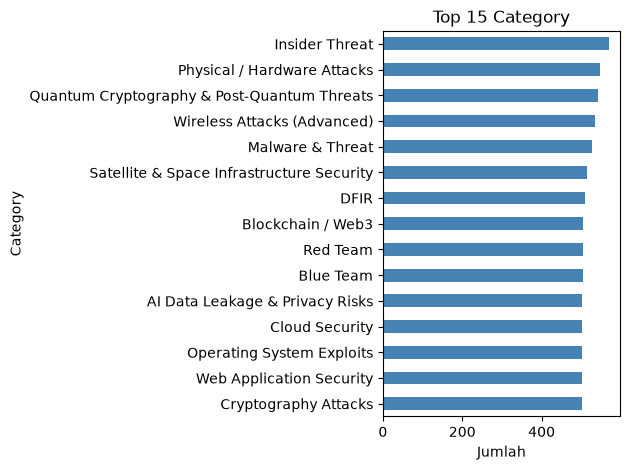

In [23]:
df['Category'].value_counts().head(15).plot(kind='barh', color='steelblue')
plt.title('Top 15 Category')
plt.xlabel('Jumlah')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [25]:
# Split, explode, strip
tools = df['Tools Used'].dropna().str.split(',').explode().str.strip()

# Hitung frekuensi
tools_count = tools.value_counts()
print("Total unique tools:", tools_count.shape[0])
print("\nTop 15 Tools:")
print(tools_count.head(15))

Total unique tools: 14906

Top 15 Tools:
Tools Used
Burp Suite        1117
Wireshark          711
Python             507
curl               486
Postman            289
PowerShell         265
bash               251
Scapy              234
Browser            196
PyTorch            190
Ghidra             184
AFL++              182
GitHub             180
Hardhat            177
Android Studio     166
Name: count, dtype: int64


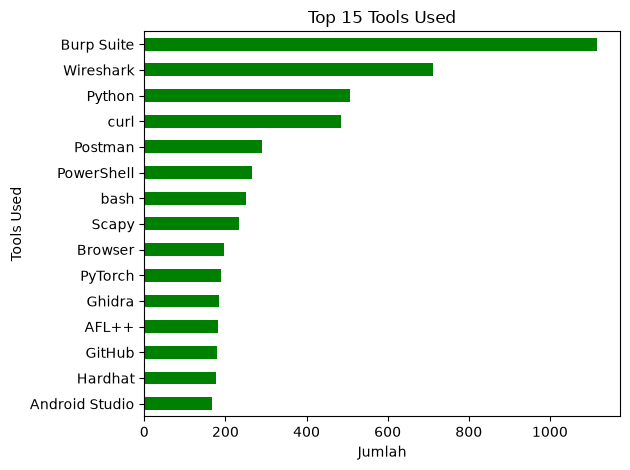

In [26]:
tools_count.head(15).plot(kind='barh', color='green')
plt.title('Top 15 Tools Used')
plt.xlabel('Jumlah')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [30]:
import re

def extract_mitre(x):
    return re.findall(r'T\d{4}(?:\.\d{3})?', str(x))

mitre = df['MITRE Technique'].dropna().apply(extract_mitre).explode()
mitre_count = mitre.value_counts()

print("Total unique MITRE technique:", mitre_count.shape[0])
print(mitre_count.head(15))

Total unique MITRE technique: 772
MITRE Technique
T1203        740
T1499        401
T1606        352
T1552.001    302
T1040        280
T1557        280
T1609        271
T1600        259
T1059        239
T1204.002    235
T1059.007    219
T1078        213
T1557.002    202
T1190        196
T1530        188
Name: count, dtype: int64


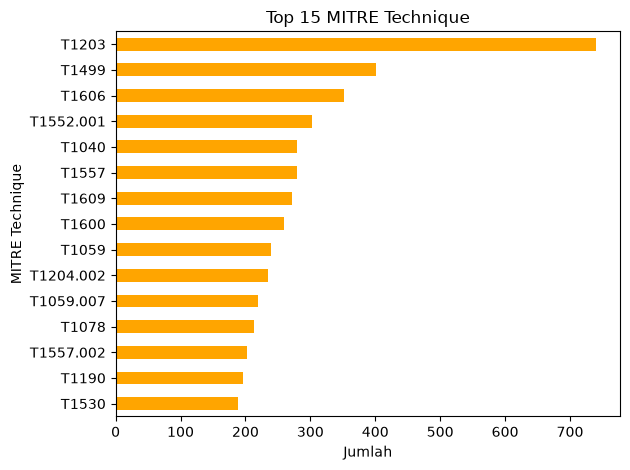

In [31]:
mitre_count.head(15).plot(kind='barh', color='orange')
plt.title('Top 15 MITRE Technique')
plt.xlabel('Jumlah')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [32]:
# Mapping manual untuk teknik yang sering muncul
mitre_names = {
    'T1190': 'Exploit Public-Facing App',
    'T1078': 'Valid Accounts',
    'T1059': 'Command & Scripting Interpreter',
    'T1059.007': 'JavaScript Execution',
    'T1110': 'Brute Force',
    'T1110.001': 'Password Guessing',
    'T1110.004': 'Credential Stuffing',
    'T1505.003': 'Web Shell / SQL Injection',
    'T1530': 'Data from Local System',
    'T1552': 'Unsecured Credentials',
    'T1552.001': 'Credentials in Files',
    'T1555.003': 'Credentials from Password Stores',
    'T1040': 'Network Sniffing',
    'T1048': 'Exfiltration Over Alt Protocol',
    'T1075': 'Pass the Session',
    'T1189': 'Drive-by Compromise',
    'T1203': 'Exploitation for Client Exec',
    'T1556.004': 'MFA Bypass',
    'T1589': 'Gather Victim Identity Info',
    'T1606.001': 'Forge Web Credentials',
}

# Tambahkan nama ke tabel
mitre_df = mitre_count.head(15).reset_index()
mitre_df.columns = ['MITRE Code', 'Count']
mitre_df['Technique Name'] = mitre_df['MITRE Code'].map(mitre_names).fillna('Unknown')
print(mitre_df)

   MITRE Code  Count                   Technique Name
0       T1203    740     Exploitation for Client Exec
1       T1499    401                          Unknown
2       T1606    352                          Unknown
3   T1552.001    302             Credentials in Files
4       T1040    280                 Network Sniffing
5       T1557    280                          Unknown
6       T1609    271                          Unknown
7       T1600    259                          Unknown
8       T1059    239  Command & Scripting Interpreter
9   T1204.002    235                          Unknown
10  T1059.007    219             JavaScript Execution
11      T1078    213                   Valid Accounts
12  T1557.002    202                          Unknown
13      T1190    196        Exploit Public-Facing App
14      T1530    188           Data from Local System


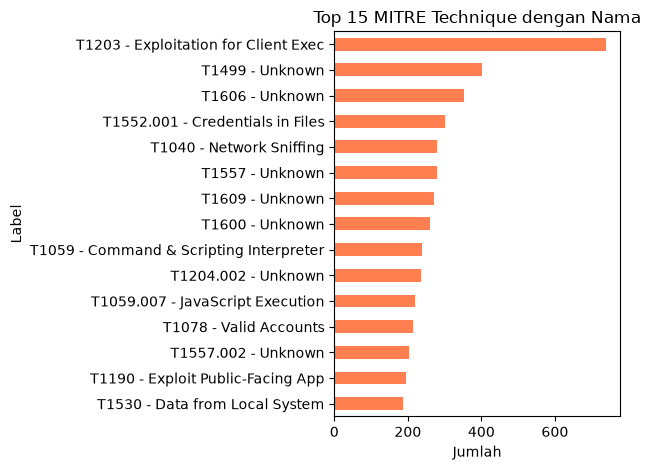

In [33]:
# Gabung kode + nama untuk label
mitre_df['Label'] = mitre_df['MITRE Code'] + ' - ' + mitre_df['Technique Name']

mitre_df.set_index('Label')['Count'].plot(kind='barh', color='coral')
plt.title('Top 15 MITRE Technique dengan Nama')
plt.xlabel('Jumlah')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()